# Versao 3 - Teste Streaming

Notebook de teste refatorado para processar o conjunto 3W em streaming, sem materializar todas as janelas em memoria.

## 1. Configuracao

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import json
import math

CURRENT_DIR = Path.cwd().resolve()
CANDIDATE_DIRS = [
    CURRENT_DIR,
    CURRENT_DIR / "versao3",
    CURRENT_DIR.parent / "versao3",
]
NOTEBOOK_DIR = next((candidate for candidate in CANDIDATE_DIRS if (candidate / "pipeline_v3.py").exists()), CURRENT_DIR)
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from pipeline_v3 import *

set_seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


In [2]:
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name in {"versao1", "versao2", "versao3"} else CURRENT_DIR
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
PREPROCESSED_V3_DIR = ARTIFACTS_DIR / "preprocessed_v3"
BUNDLE_PATH = PREPROCESSED_V3_DIR / "preprocessing_bundle_v3.json"
MODEL_CONFIG_PATH = ARTIFACTS_DIR / "models" / "hybrid_residual_forecaster_v3_config.json"
MODEL_PATH = ARTIFACTS_DIR / "models" / "hybrid_residual_forecaster_v3.pt"

BATCH_SIZE = 512
MAX_SERIES = None
MAX_BATCHES = None
MAX_WINDOWS = None
PROGRESS_EVERY = 25
PREVIEW_ROWS = 2048
PLOT_SAMPLE_ROWS = 500

ENABLE_EXPORT = False
EXPORT_SCALE = "original"
EXPORT_CHUNK_ROWS = 250_000
EXPORT_DIR = ARTIFACTS_DIR / "predictions_v3_streaming"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pd.DataFrame(
    {
        "configuracao": [
            "device",
            "batch_size",
            "max_series",
            "max_batches",
            "max_windows",
            "progress_every",
            "preview_rows",
            "enable_export",
            "export_scale",
            "export_chunk_rows",
        ],
        "valor": [
            str(device),
            BATCH_SIZE,
            MAX_SERIES,
            MAX_BATCHES,
            MAX_WINDOWS,
            PROGRESS_EVERY,
            PREVIEW_ROWS,
            ENABLE_EXPORT,
            EXPORT_SCALE,
            EXPORT_CHUNK_ROWS,
        ],
    }
)


,configuracao,valor
0,device,cuda
1,batch_size,512
2,max_series,None
3,max_batches,None
4,max_windows,None
5,progress_every,25
6,preview_rows,2048
7,enable_export,False
8,export_scale,original
9,export_chunk_rows,250000


## 2. Carga do Modelo e dos Dados

In [3]:
bundle = load_bundle(BUNDLE_PATH)
model_config = json.loads(MODEL_CONFIG_PATH.read_text())
RAW_TARGET_POSITIONS = model_config["raw_target_positions"]

model = HybridResidualForecaster(
    input_size=model_config["input_size"],
    target_size=model_config["target_size"],
    well_count=max(len(bundle.well_to_id), 1),
    raw_target_positions=RAW_TARGET_POSITIONS,
    model_dim=model_config["model_dim"],
    gru_hidden_size=model_config["gru_hidden_size"],
    gru_layers=model_config["gru_layers"],
    well_embedding_dim=model_config["well_embedding_dim"],
    dropout=model_config["dropout"],
).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_test_groups = load_grouped_sequences_from_directory(
    PREPROCESSED_V3_DIR / "test",
    input_columns=bundle.input_columns,
    target_columns=bundle.target_columns,
)
# Limitar series antes de montar o dataset deixa o modo debug muito mais barato.
test_groups = limit_groups_for_inference(all_test_groups, max_series=MAX_SERIES)

test_dataset = GroupedWindowDataset(
    groups=test_groups,
    sequence_length=model_config["sequence_length"],
    sampled_windows=None,
    seed=999,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda",
)

estimated_windows = count_group_windows(test_groups, model_config["sequence_length"])
if MAX_WINDOWS is not None:
    estimated_windows = min(estimated_windows, MAX_WINDOWS)
if MAX_BATCHES is not None:
    estimated_windows = min(estimated_windows, MAX_BATCHES * BATCH_SIZE)
estimated_batches = math.ceil(estimated_windows / BATCH_SIZE) if estimated_windows else 0

runtime_df = pd.DataFrame(
    {
        "aspecto": [
            "model_name",
            "sequence_length",
            "series_de_teste_total",
            "series_de_teste_utilizadas",
            "janelas_estimadas",
            "batches_estimados",
        ],
        "valor": [
            model_config["model_name"],
            model_config["sequence_length"],
            len(all_test_groups),
            len(test_groups),
            estimated_windows,
            estimated_batches,
        ],
    }
)
display(runtime_df)


,aspecto,valor
0,model_name,hybrid_residual_forecaster_v3
1,sequence_length,60
2,series_de_teste_total,360
3,series_de_teste_utilizadas,360
4,janelas_estimadas,12383387
5,batches_estimados,24187


## 3. Inferencia Streaming

In [4]:
streaming_result = predict_loader_streaming(
    model=model,
    loader=test_loader,
    device=device,
    raw_target_positions=RAW_TARGET_POSITIONS,
    groups=test_groups,
    bundle=bundle,
    collect_metrics=True,
    export_predictions=ENABLE_EXPORT,
    export_dir=EXPORT_DIR if ENABLE_EXPORT else None,
    export_chunk_rows=EXPORT_CHUNK_ROWS,
    export_scale=EXPORT_SCALE,
    preview_rows=PREVIEW_ROWS,
    max_batches=MAX_BATCHES,
    max_windows=MAX_WINDOWS,
    progress_every=PROGRESS_EVERY,
    log_memory=True,
)

preview_df = streaming_result.preview_df.copy()

inference_summary_df = pd.DataFrame(
    {
        "aspecto": [
            "processed_batches",
            "processed_windows",
            "total_batches_estimate",
            "total_windows_estimate",
            "elapsed_seconds",
            "preview_rows_retained",
            "export_files",
        ],
        "valor": [
            streaming_result.processed_batches,
            streaming_result.processed_windows,
            streaming_result.total_batches_estimate,
            streaming_result.total_windows_estimate,
            round(streaming_result.elapsed_seconds, 2),
            len(preview_df),
            len(streaming_result.export_files),
        ],
    }
)
display(inference_summary_df)

if not preview_df.empty:
    display(preview_df.head())
else:
    print("Nenhuma linha foi mantida para preview. Aumente PREVIEW_ROWS se quiser inspecionar amostras.")


[predict_loader_streaming] batch 25/24187 | janelas 12,800/12,383,387 (  0.1%) | tempo 00:00 | eta 07:54 | ultimo_batch 0.004s | mem 4,689 MB
[predict_loader_streaming] batch 50/24187 | janelas 25,600/12,383,387 (  0.2%) | tempo 00:01 | eta 06:56 | ultimo_batch 0.004s | mem 4,689 MB
[predict_loader_streaming] batch 75/24187 | janelas 38,400/12,383,387 (  0.3%) | tempo 00:01 | eta 06:26 | ultimo_batch 0.005s | mem 4,689 MB
[predict_loader_streaming] batch 100/24187 | janelas 51,200/12,383,387 (  0.4%) | tempo 00:02 | eta 06:03 | ultimo_batch 0.004s | mem 4,689 MB
[predict_loader_streaming] batch 125/24187 | janelas 64,000/12,383,387 (  0.5%) | tempo 00:02 | eta 06:04 | ultimo_batch 0.005s | mem 4,689 MB
[predict_loader_streaming] batch 150/24187 | janelas 76,800/12,383,387 (  0.6%) | tempo 00:02 | eta 06:15 | ultimo_batch 0.005s | mem 4,689 MB
[predict_loader_streaming] batch 175/24187 | janelas 89,600/12,383,387 (  0.7%) | tempo 00:03 | eta 06:22 | ultimo_batch 0.005s | mem 4,689 MB
[p

,aspecto,valor
0,processed_batches,24187.00
1,processed_windows,12383387.00
2,total_batches_estimate,24187.00
3,total_windows_estimate,12383387.00
4,elapsed_seconds,339.62
5,preview_rows_retained,2048.00
6,export_files,0.00


,series_id,well_name,class_label,source_type,step_idx,timestamp,real__P-ANULAR,pred__P-ANULAR,persist__P-ANULAR,real__P-JUS-CKGL,pred__P-JUS-CKGL,persist__P-JUS-CKGL,real__P-MON-CKP,pred__P-MON-CKP,persist__P-MON-CKP,real__P-TPT,pred__P-TPT,persist__P-TPT,real__T-JUS-CKP,pred__T-JUS-CKP,persist__T-JUS-CKP,real__T-TPT,pred__T-TPT,persist__T-TPT,real_scaled__P-ANULAR,pred_scaled__P-ANULAR,persist_scaled__P-ANULAR,real_scaled__P-JUS-CKGL,pred_scaled__P-JUS-CKGL,persist_scaled__P-JUS-CKGL,real_scaled__P-MON-CKP,pred_scaled__P-MON-CKP,persist_scaled__P-MON-CKP,real_scaled__P-TPT,pred_scaled__P-TPT,persist_scaled__P-TPT,real_scaled__T-JUS-CKP,pred_scaled__T-JUS-CKP,persist_scaled__T-JUS-CKP,real_scaled__T-TPT,pred_scaled__T-TPT,persist_scaled__T-TPT
0,0__WELL-00001_20170825110000,WELL-00001,0,well,60,2017-08-25 11:01:00,11499810.0,11499450.0,11499840.0,-142577.0,-142708.0,-142577.0,1391547.125,1389268.625,1388785.250,9665080.0,9664626.0,9665121.0,83.250069,83.239998,83.238869,118.473396,118.476501,118.473396,0.766638,0.766594,0.766641,-0.634014,-0.634026,-0.634014,-0.525649,-0.526365,-0.526516,-0.386342,-0.386398,-0.386337,0.924140,0.923825,0.923790,0.843988,0.844056,0.843988
1,0__WELL-00001_20170825110000,WELL-00001,0,well,61,2017-08-25 11:01:01,11499770.0,11499449.0,11499810.0,-142577.5,-142719.0,-142577.0,1394309.250,1392253.250,1391547.125,9665040.0,9664679.0,9665080.0,83.261276,83.250793,83.250069,118.473396,118.476044,118.473396,0.766633,0.766594,0.766638,-0.634014,-0.634027,-0.634014,-0.524782,-0.525428,-0.525649,-0.386347,-0.386391,-0.386342,0.924491,0.924163,0.924140,0.843988,0.844046,0.843988
2,0__WELL-00001_20170825110000,WELL-00001,0,well,62,2017-08-25 11:01:02,11499730.0,11499427.0,11499770.0,-142577.5,-142729.0,-142577.5,1397071.125,1395228.750,1394309.250,9664999.0,9664690.0,9665040.0,83.272476,83.261856,83.261276,118.473396,118.475456,118.473396,0.766628,0.766591,0.766633,-0.634014,-0.634028,-0.634014,-0.523915,-0.524493,-0.524782,-0.386352,-0.386390,-0.386347,0.924842,0.924510,0.924491,0.843988,0.844033,0.843988
3,0__WELL-00001_20170825110000,WELL-00001,0,well,63,2017-08-25 11:01:03,11499700.0,11499405.0,11499730.0,-142578.0,-142712.5,-142577.5,1399833.250,1397699.625,1397071.125,9664958.0,9664719.0,9664999.0,83.283684,83.272873,83.272476,118.473396,118.475189,118.473396,0.766624,0.766589,0.766628,-0.634014,-0.634026,-0.634014,-0.523047,-0.523717,-0.523915,-0.386357,-0.386386,-0.386352,0.925193,0.924855,0.924842,0.843988,0.844028,0.843988
4,0__WELL-00001_20170825110000,WELL-00001,0,well,64,2017-08-25 11:01:04,11499660.0,11499384.0,11499700.0,-142578.5,-142711.5,-142578.0,1402595.125,1400483.125,1399833.250,9664918.0,9664674.0,9664958.0,83.294884,83.284088,83.283684,118.473396,118.475098,118.473396,0.766620,0.766586,0.766624,-0.634014,-0.634026,-0.634014,-0.522180,-0.522843,-0.523047,-0.386362,-0.386392,-0.386357,0.925544,0.925206,0.925193,0.843988,0.844026,0.843988


## 4. Metricas

In [5]:
global_metrics_scaled_df = streaming_result.global_metrics_scaled_df.copy()
global_metrics_original_df = streaming_result.global_metrics_original_df.copy()

print("Escala padronizada")
display(global_metrics_scaled_df)
print("Escala original")
display(global_metrics_original_df)


Escala padronizada


,modelo,MSE,RMSE,MAE,R2_medio,mse_melhora_pct,rmse_melhora_pct,mae_melhora_pct
0,Modelo_v3,0.000002,0.001260,0.000224,0.999998,65.564561,41.318283,33.202522
1,Persistencia,0.000005,0.002147,0.000336,0.999995,NaN,NaN,NaN


Escala original


,modelo,MSE,RMSE,MAE,R2_medio,mse_melhora_pct,rmse_melhora_pct,mae_melhora_pct
0,Modelo_v3,2.112063e+07,4595.718393,703.941560,0.999998,58.542059,35.612158,32.17229
1,Persistencia,5.094471e+07,7137.556228,1037.837721,0.999995,NaN,NaN,NaN


In [6]:
per_feature_scaled_df = streaming_result.per_feature_scaled_df.copy()
per_feature_original_df = streaming_result.per_feature_original_df.copy()
class_level_metrics_df = streaming_result.class_metrics_original_df.copy()

print("Por feature - escala padronizada")
display(per_feature_scaled_df)
print("Por feature - escala original")
display(per_feature_original_df)
print("Por classe - escala original")
class_level_metrics_df


Por feature - escala padronizada


,feature,model_mae,baseline_mae,mae_melhora_pct,model_mse,baseline_mse,model_rmse,baseline_rmse,rmse_melhora_pct,model_r2,baseline_r2,model_bias,model_residual_std
0,P-MON-CKP,0.000753,0.001580,52.354369,7.739292e-06,2.532591e-05,0.002782,0.005032,44.719992,0.999991,0.999971,3.093225e-05,0.002782
1,T-JUS-CKP,0.000228,0.000199,-14.845909,7.574611e-07,1.214348e-06,0.000870,0.001102,21.021557,0.999999,0.999999,5.306847e-05,0.000869
2,P-ANULAR,0.000083,0.000045,-84.690237,5.820925e-07,5.821441e-07,0.000763,0.000763,0.004426,0.999999,0.999999,8.506395e-07,0.000763
3,T-TPT,0.000151,0.000095,-59.725739,3.230083e-07,4.106190e-07,0.000568,0.000641,11.307415,1.000000,1.000000,-4.682423e-05,0.000566
4,P-TPT,0.000104,0.000086,-21.462917,1.158465e-07,1.280364e-07,0.000340,0.000358,4.879357,1.000000,1.000000,7.620139e-06,0.000340
5,P-JUS-CKGL,0.000027,0.000012,-131.013702,1.037430e-08,8.329606e-09,0.000102,0.000091,-11.600784,1.000000,1.000000,-1.019380e-05,0.000101


Por feature - escala original


,feature,model_mae,baseline_mae,mae_melhora_pct,model_mse,baseline_mse,model_rmse,baseline_rmse,rmse_melhora_pct,model_r2,baseline_r2,model_bias,model_residual_std
0,P-MON-CKP,2397.043472,5031.009910,52.354626,7.849335e+07,2.568601e+08,8859.647541,16026.855977,44.719990,0.999991,0.999971,98.518150,8859.099770
1,P-ANULAR,678.921140,367.601432,-84.689471,3.925987e+07,3.926332e+07,6265.769416,6266.044892,0.004396,0.999999,0.999999,6.955587,6265.765556
2,P-TPT,849.511229,699.401435,-21.462609,7.747872e+06,8.563142e+06,2783.500014,2926.284719,4.879385,1.000000,1.000000,62.337441,2782.801893
3,P-JUS-CKGL,298.159311,129.002872,-131.126103,1.222672e+06,9.816801e+05,1105.745015,990.797705,-11.601491,1.000000,1.000000,-110.687832,1100.191002
4,T-JUS-CKP,0.007283,0.006342,-14.845582,7.719409e-04,1.237563e-03,0.027784,0.035179,21.021597,0.999999,0.999999,0.001693,0.027732
5,T-TPT,0.006924,0.004335,-59.734038,6.759020e-04,8.592260e-04,0.025998,0.029313,11.307238,1.000000,1.000000,-0.002143,0.025910


Por classe - escala original


,modelo,MSE,RMSE,MAE,R2_medio
0,Modelo_v3_classe_0,3.810221e+06,1951.978623,389.036330,1.000000
1,Persistencia_classe_0,1.500631e+07,3873.798509,586.843943,0.999999
2,Modelo_v3_classe_1,4.916316e+06,2217.276748,217.340291,0.999996
3,Persistencia_classe_1,5.968666e+06,2443.085428,179.670205,0.999994
4,Modelo_v3_classe_2,4.164035e+06,2040.596742,360.244897,0.999999
5,Persistencia_classe_2,4.424756e+06,2103.510376,173.426557,0.999999
6,Modelo_v3_classe_3,3.068610e+06,1751.744893,541.066973,1.000000
7,Persistencia_classe_3,5.759210e+06,2399.835494,707.626193,0.999999
8,Modelo_v3_classe_4,2.548330e+06,1596.348880,562.038604,0.999999
9,Persistencia_classe_4,3.990514e+06,1997.627083,558.673763,0.999998


## 5. Exportacao Opcional

In [7]:
if ENABLE_EXPORT:
    export_summary_df = pd.DataFrame(
        {
            "arquivo": [Path(file_path).name for file_path in streaming_result.export_files],
            "caminho": [str(Path(file_path)) for file_path in streaming_result.export_files],
        }
    )
    print(f"{len(streaming_result.export_files)} arquivo(s) Parquet gerado(s) em {EXPORT_DIR}.")
    display(export_summary_df.head(10))
else:
    print("Exportacao desativada. Defina ENABLE_EXPORT=True para salvar previsoes em Parquet por chunks.")


Exportacao desativada. Defina ENABLE_EXPORT=True para salvar previsoes em Parquet por chunks.


## 6. Visualizacao de Amostras

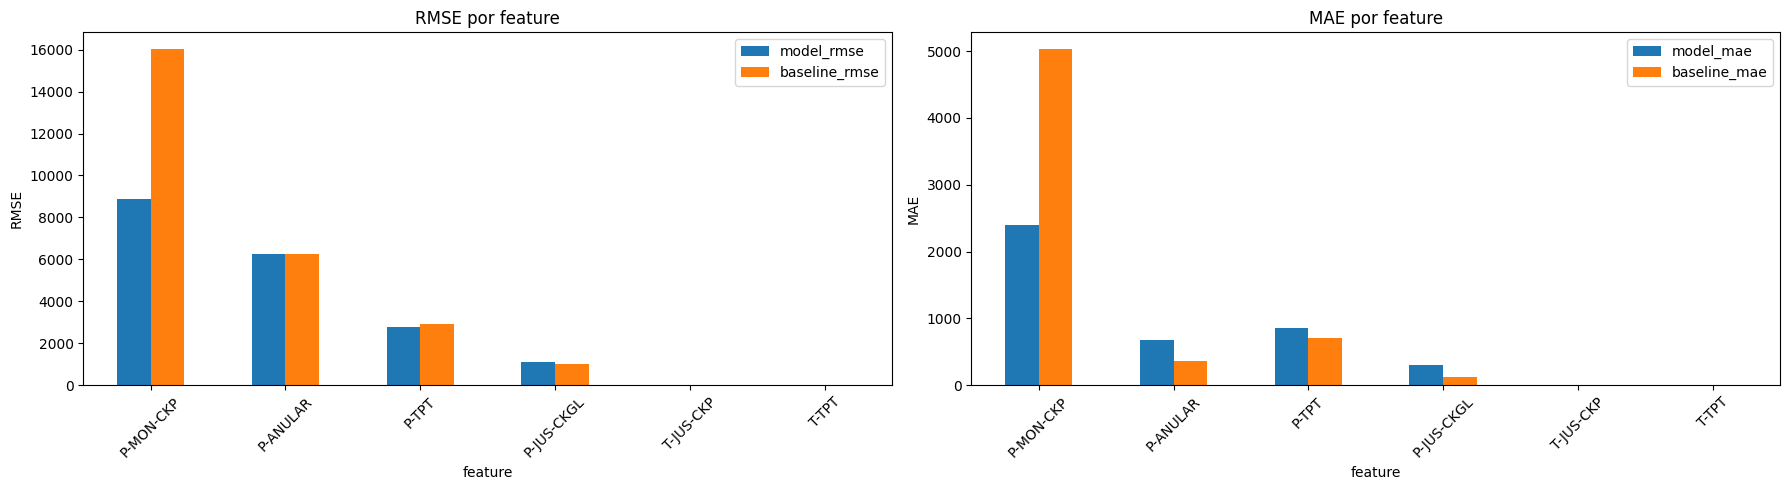

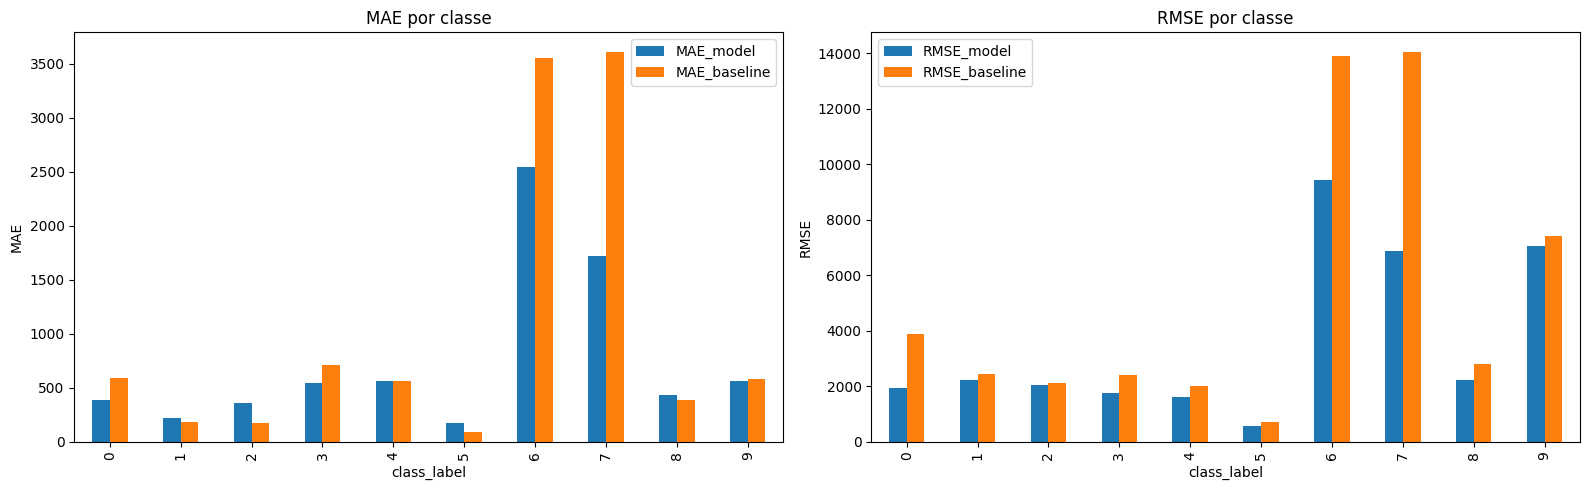

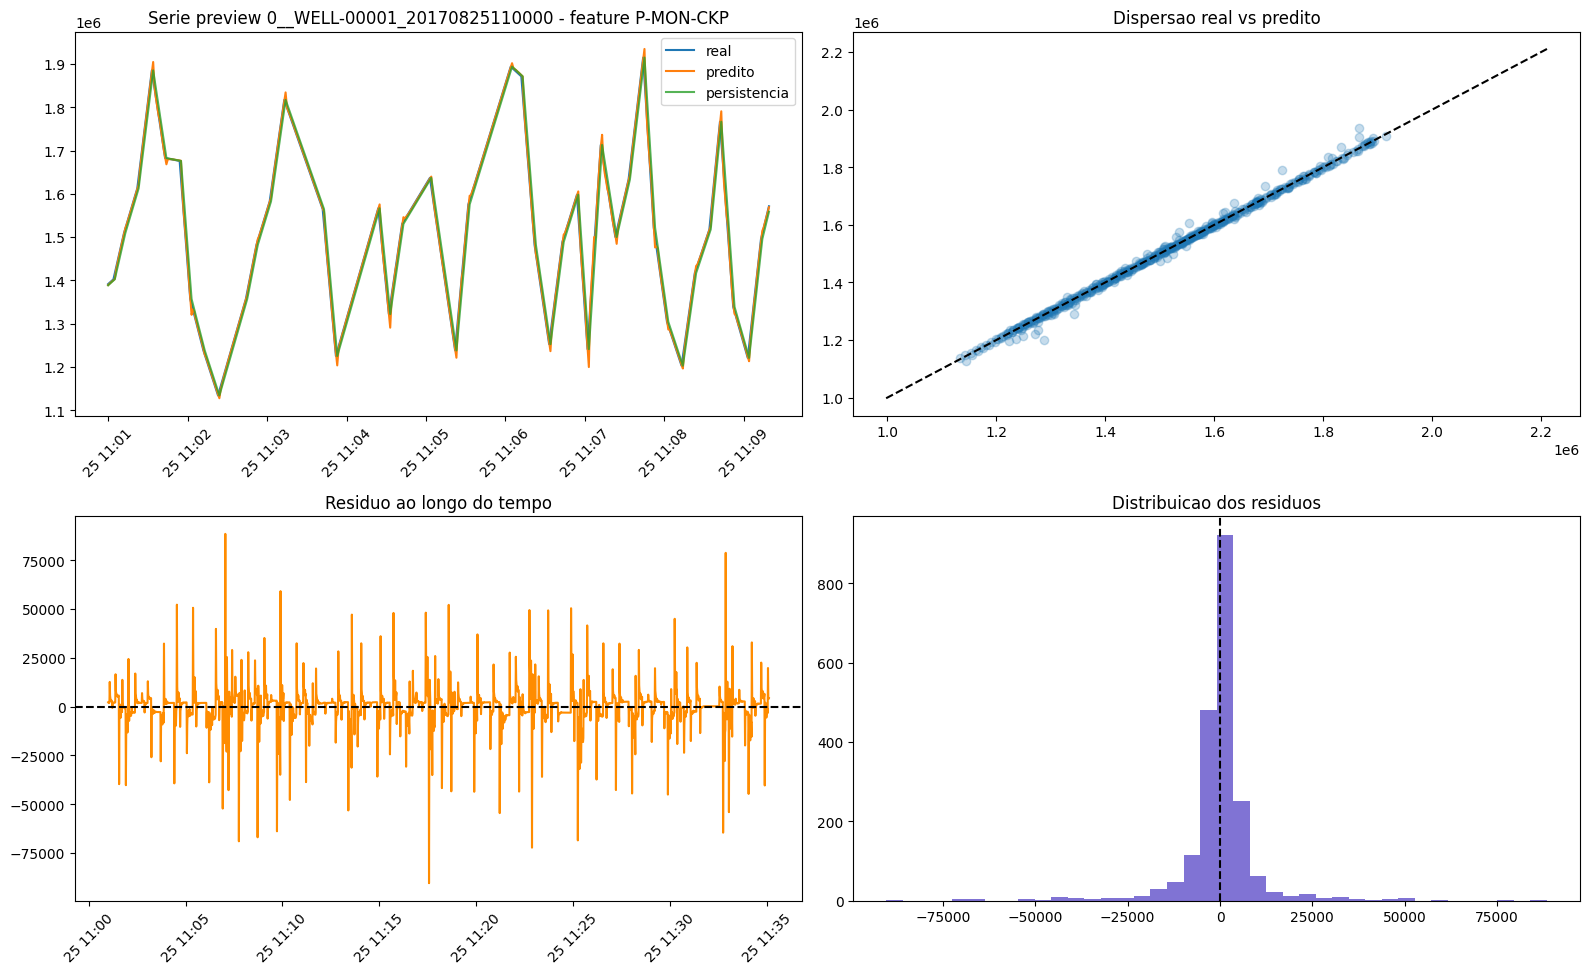

,timestamp,real__P-MON-CKP,pred__P-MON-CKP,persist__P-MON-CKP
0,2017-08-25 11:01:00,1391547.125,1389268.625,1388785.250
1,2017-08-25 11:01:01,1394309.250,1392253.250,1391547.125
2,2017-08-25 11:01:02,1397071.125,1395228.750,1394309.250
3,2017-08-25 11:01:03,1399833.250,1397699.625,1397071.125
4,2017-08-25 11:01:04,1402595.125,1400483.125,1399833.250


In [8]:
compare_plot_df = per_feature_original_df.set_index("feature")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
compare_plot_df[["model_rmse", "baseline_rmse"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("RMSE por feature")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=45)

compare_plot_df[["model_mae", "baseline_mae"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("MAE por feature")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

if not class_level_metrics_df.empty:
    model_rows = class_level_metrics_df[class_level_metrics_df["modelo"].str.startswith("Modelo_v3_")].copy()
    baseline_rows = class_level_metrics_df[class_level_metrics_df["modelo"].str.startswith("Persistencia_")].copy()
    model_rows["class_label"] = model_rows["modelo"].str.rsplit("_", n=1).str[-1]
    baseline_rows["class_label"] = baseline_rows["modelo"].str.rsplit("_", n=1).str[-1]
    class_compare_df = model_rows.merge(
        baseline_rows[["class_label", "MAE", "RMSE"]],
        on="class_label",
        suffixes=("_model", "_baseline"),
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    class_compare_df.plot(kind="bar", x="class_label", y=["MAE_model", "MAE_baseline"], ax=axes[0])
    axes[0].set_title("MAE por classe")
    axes[0].set_ylabel("MAE")

    class_compare_df.plot(kind="bar", x="class_label", y=["RMSE_model", "RMSE_baseline"], ax=axes[1])
    axes[1].set_title("RMSE por classe")
    axes[1].set_ylabel("RMSE")

    plt.tight_layout()
    plt.show()

if preview_df.empty:
    raise ValueError("O preview ficou vazio. Aumente PREVIEW_ROWS para habilitar as visualizacoes locais.")

preview_series_id = preview_df["series_id"].iloc[0]
worst_feature = per_feature_original_df.iloc[0]["feature"]
local_preview_df = preview_df[preview_df["series_id"] == preview_series_id].copy()
local_preview_df = local_preview_df.sort_values("timestamp").reset_index(drop=True)

real_local = local_preview_df[f"real__{worst_feature}"].to_numpy(dtype=np.float32)
pred_local = local_preview_df[f"pred__{worst_feature}"].to_numpy(dtype=np.float32)
persist_local = local_preview_df[f"persist__{worst_feature}"].to_numpy(dtype=np.float32)
residual_local = real_local - pred_local
window_limit = min(PLOT_SAMPLE_ROWS, len(local_preview_df))
scatter_points = min(PLOT_SAMPLE_ROWS, len(local_preview_df))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].plot(local_preview_df["timestamp"].iloc[:window_limit], real_local[:window_limit], label="real")
axes[0, 0].plot(local_preview_df["timestamp"].iloc[:window_limit], pred_local[:window_limit], label="predito")
axes[0, 0].plot(local_preview_df["timestamp"].iloc[:window_limit], persist_local[:window_limit], label="persistencia", alpha=0.8)
axes[0, 0].set_title(f"Serie preview {preview_series_id} - feature {worst_feature}")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].legend()

axes[0, 1].scatter(real_local[:scatter_points], pred_local[:scatter_points], alpha=0.25, label="modelo")
min_axis = min(real_local.min(), pred_local.min(), persist_local.min())
max_axis = max(real_local.max(), pred_local.max(), persist_local.max())
axes[0, 1].plot([min_axis, max_axis], [min_axis, max_axis], color="black", linestyle="--")
axes[0, 1].set_title("Dispersao real vs predito")

axes[1, 0].plot(local_preview_df["timestamp"], residual_local, color="darkorange")
axes[1, 0].axhline(0.0, color="black", linestyle="--")
axes[1, 0].set_title("Residuo ao longo do tempo")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].hist(residual_local, bins=40, color="slateblue", alpha=0.85)
axes[1, 1].axvline(0.0, color="black", linestyle="--")
axes[1, 1].set_title("Distribuicao dos residuos")

plt.tight_layout()
plt.show()

local_preview_df[["timestamp", f"real__{worst_feature}", f"pred__{worst_feature}", f"persist__{worst_feature}"]].head()
